## Импорт библиотек

In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import OrdinalEncoder, CatBoostEncoder
from sklearn.compose import ColumnTransformer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from helper import divide_data, evaluate_classification
from plots import plot_feature_importance

In [ ]:
# фиксируем состояние генератора псевдослучайных чисел.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 1. Препроцессинг данных

In [5]:
df = pd.read_csv("./Telecom_Customer_Churn.csv")

In [6]:
NUMERICAL_FEATURES_LIST = ["tenure", "MonthlyCharges", "TotalCharges"]

CATEGORICAL_FEATURES_LIST = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

TARGET = "Churn"

### 1.1 Общие преобразования

In [7]:
df_preprocessed = df.copy()

In [8]:
# Удаляем столбец customerID, поскольку он не несет пользы в дальнейшем исследовании
df_preprocessed = df_preprocessed.drop(columns=['customerID'])

In [9]:
# Предразование TotalCharges в float и замена пропусков на 0
df_preprocessed["TotalCharges"] = pd.to_numeric(df_preprocessed["TotalCharges"], errors="coerce")
df_preprocessed["TotalCharges"] = df_preprocessed["TotalCharges"].fillna(0)
# df_preprocessed.head(5)

In [10]:
# Кодирование таргета
df_preprocessed[TARGET] = np.where(df_preprocessed[TARGET] == 'Yes', 1, 0)

In [11]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 1.2 Разбиение датасета 

In [12]:
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, TARGET)

In [13]:
# Разбиваем данные на train и test с соотношением 80 на 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y  
)

In [14]:
X_train.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65
3151,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55
4860,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35
3867,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70
3810,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55


In [15]:
X_train_preprocessed = X_train.copy()

### 1.3 Кодирование категориальных переменных

In [17]:
# SeniorCitizen уже был закодирован в изначальном датасете
CATEGORICAL_WITHOUT_SENIOR = [
    col for col in CATEGORICAL_FEATURES_LIST if col != "SeniorCitizen"
]

#### 1.3.1 Порядковое кодирование

In [18]:
# Список для порядкого кодирования
CATEGORICAL_ORDINAL_ENC = [
    col
    for col in CATEGORICAL_WITHOUT_SENIOR
    if col not in ["gender", "InternetService", "PaymentMethod"]
]

In [ ]:
# Создаем словарь mapping для каждого признака
ordinal_mapping = [
    {'col': 'Partner', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'Dependents', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'PhoneService', 'mapping': {'No': 0, 'Yes': 1}},
    {'col': 'MultipleLines', 'mapping': {'No phone service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'OnlineSecurity', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'OnlineBackup', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'DeviceProtection', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'TechSupport', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'StreamingTV', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'StreamingMovies', 'mapping': {'No internet service': 0, 'No': 1, 'Yes': 2}},
    {'col': 'Contract', 'mapping': {'Month-to-month': 0, 'One year': 1, 'Two year': 2}},
    {'col': 'PaperlessBilling', 'mapping': {'No': 0, 'Yes': 1}}
]

# Создаем кодировщик
encoder = OrdinalEncoder(cols=CATEGORICAL_ORDINAL_ENC, mapping=ordinal_mapping)

# Применяем кодировку
X_train_preprocessed = encoder.fit_transform(X_train_preprocessed)

#### 1.3.2 CatBoostEncoder

In [ ]:
# Признаки для кодировки с помощью CatBoostEncoder, так как они не имеют порядка
CATEGORICAL_CATBOOST_ENC = ["gender", "InternetService", "PaymentMethod"]

In [ ]:
catboost_encoder = CatBoostEncoder(cols=CATEGORICAL_CATBOOST_ENC)
X_train_encoded = catboost_encoder.fit_transform(X_train_preprocessed, y_train)

### 1.4 Preprocessor Pipeline

In [23]:
X_train_preprocessed = X_train.copy()

In [ ]:
preprocessor = ColumnTransformer(
    [
        # Числовые признаки: скалирование
        ("scaler_numerical", StandardScaler(), NUMERICAL_FEATURES_LIST),
        # Порядковые категориальные признаки
        (
            "ordinal_categorical",
            OrdinalEncoder(
                cols=CATEGORICAL_ORDINAL_ENC,
                mapping=ordinal_mapping,
                handle_unknown="value",
                handle_missing="value",
            ),
            CATEGORICAL_ORDINAL_ENC,
        ),
        # Категориальные признаки для CatBoost Encoding
        (
            "catboost_categorical",
            CatBoostEncoder(
                cols=CATEGORICAL_CATBOOST_ENC,
                sigma=None,
                a=1.0,
                handle_unknown="value",
                handle_missing="value",
                random_state=42,
            ),
            CATEGORICAL_CATBOOST_ENC,
        ),
    ],
    remainder="passthrough",  # колонки, не указанные в трансформерах, передаются без изменений
    verbose_feature_names_out=False,  # не добавлять префиксы к именам колонок
)

# Устанавливаем вывод в формате pandas DataFrame
preprocessor.set_output(transform="pandas")

,transformers,"[('scaler_numerical', ...), ('ordinal_categorical', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [25]:
X_train_preprocessed = preprocessor.fit_transform(X_train, y_train)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, index=X_train.index)

In [26]:
X_train_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure            5634 non-null   float64
 1   MonthlyCharges    5634 non-null   float64
 2   TotalCharges      5634 non-null   float64
 3   Partner           5634 non-null   int64  
 4   Dependents        5634 non-null   int64  
 5   PhoneService      5634 non-null   int64  
 6   MultipleLines     5634 non-null   int64  
 7   OnlineSecurity    5634 non-null   int64  
 8   OnlineBackup      5634 non-null   int64  
 9   DeviceProtection  5634 non-null   int64  
 10  TechSupport       5634 non-null   int64  
 11  StreamingTV       5634 non-null   int64  
 12  StreamingMovies   5634 non-null   int64  
 13  Contract          5634 non-null   int64  
 14  PaperlessBilling  5634 non-null   int64  
 15  gender            5634 non-null   float64
 16  InternetService   5634 non-null   float64
 1

## 2. Построение базовой модели (Baseline)

In [27]:
# Применяем обученный пайплайн к тестовой выборке. 
X_test_preprocessed = preprocessor.transform(X_test)

In [28]:
X_test_preprocessed

,tenure,MonthlyCharges,TotalCharges,Partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,gender,InternetService,PaymentMethod,SeniorCitizen
437,1.608483,1.629976,2.706828,1,1,1,2,2,2,2,2,2,2,2,1,0.264384,0.420799,0.149312,0
2280,-0.996684,1.168725,-0.610260,0,0,1,2,1,1,1,2,2,2,0,1,0.266333,0.420799,0.149312,1
2235,0.346606,0.445324,0.400116,1,1,1,2,2,2,2,1,2,1,1,1,0.266333,0.186927,0.149312,0
4460,-0.589626,0.440347,-0.364451,1,0,1,1,1,1,2,2,1,1,0,0,0.264384,0.420799,0.457328,0
3761,1.608483,0.588013,1.588421,1,0,1,2,2,2,2,1,2,2,2,1,0.266333,0.186927,0.149312,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0.672252,0.738999,0.897615,1,1,1,1,2,2,2,2,2,2,1,1,0.266333,0.186927,0.192902,0
4439,-0.182569,-1.480980,-0.794815,1,1,1,1,0,0,0,0,0,0,2,1,0.264384,0.072646,0.149312,0
3857,-1.118801,-1.469365,-0.967873,0,0,1,1,0,0,0,0,0,0,0,0,0.264384,0.072646,0.161659,0
4758,0.957192,-1.500890,-0.547360,0,0,1,1,0,0,0,0,0,0,2,0,0.266333,0.072646,0.161659,0


In [29]:
feature_names = X_test_preprocessed.columns.to_list()

### 2.1 Dummy Classifier

c:\Users\Kirill\Desktop\ML_Projects\ml-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kirill\Desktop\ML_Projects\ml-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


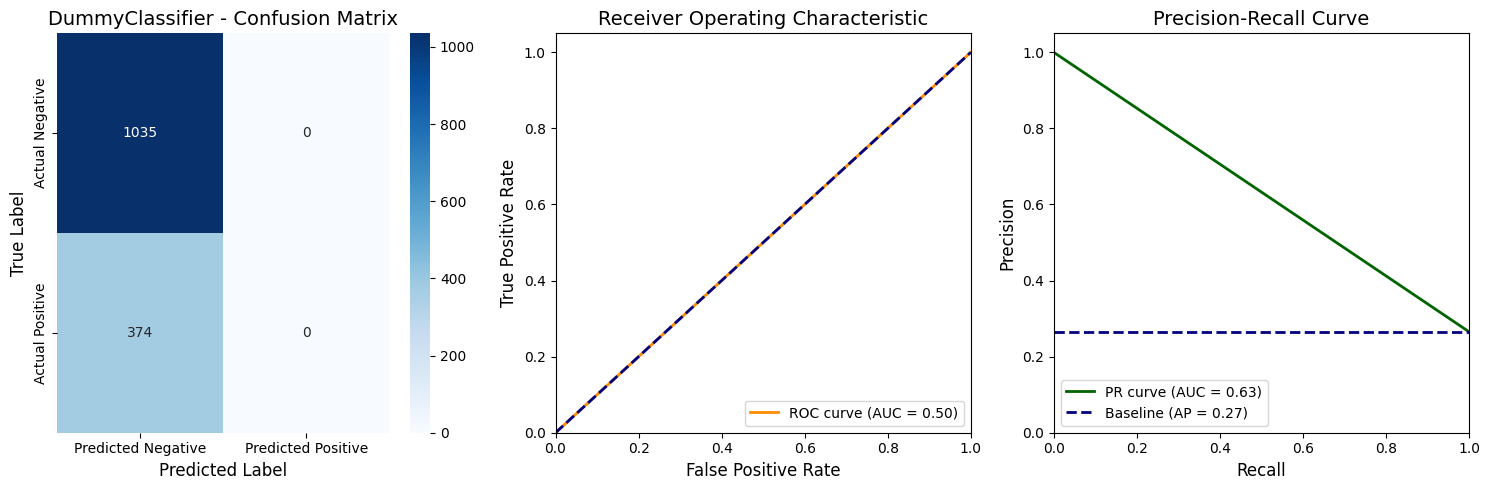


                 DUMMYCLASSIFIER EVALUATION                 

MAIN METRICS:
   Metric  Value
  ROC AUC 0.5000
   PR AUC 0.6327
 F1 Score 0.4235
Precision 0.3673
   Recall 0.5000
 Accuracy 0.7346


CLASSIFICATION REPORT:
   Class  Precision  Recall
Positive   0.000000     0.0
Negative   0.734564     1.0



In [30]:
# Задаем и обучаем модель
dummy_classifier = DummyClassifier(random_state=SEED, strategy='most_frequent')
dummy_classifier.fit(X_train_preprocessed, y_train)

# Получаем предсказания
y_pred = dummy_classifier.predict(X_test_preprocessed) # предсказываем номер класса
y_probs = dummy_classifier.predict_proba(X_test_preprocessed)[:, 1] # предсказываем вероятность (необходима для построения ROC кривой)

# Считаем метрики для модели и выводим графики
dummy_classifier_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="DummyClassifier"
)

### 2.2 Логистическая регрессия

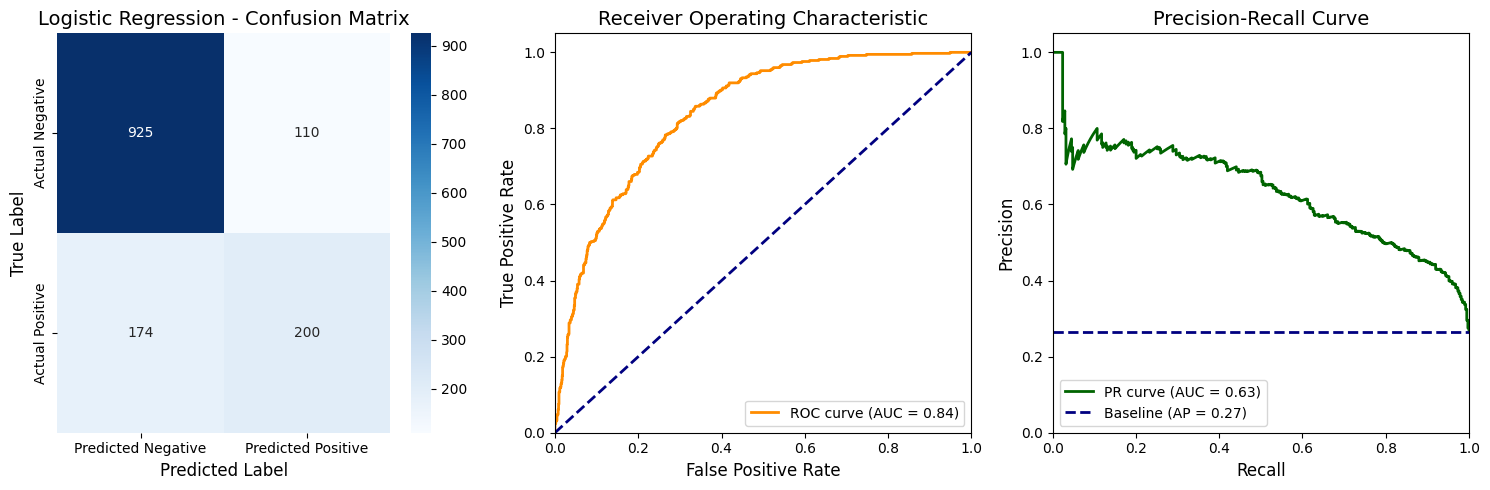


               LOGISTIC REGRESSION EVALUATION               

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8414
   PR AUC 0.6336
 F1 Score 0.7259
Precision 0.7434
   Recall 0.7142
 Accuracy 0.7984


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.645161 0.534759
Negative   0.841674 0.893720



In [ ]:
log_reg = LogisticRegression(random_state=SEED, max_iter=1000, solver="liblinear")
log_reg.fit(X_train_preprocessed, y_train)

y_pred = log_reg.predict(X_test_preprocessed)
y_probs = log_reg.predict_proba(X_test_preprocessed)[:, 1]


log_reg_metrics = evaluate_classification(
    y_test=y_test, y_pred=y_pred, y_probs=y_probs, model_name="Logistic Regression"
)

c:\Users\Kirill\Desktop\ML_Projects\ml-classification\plots.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  from matplotlib.colors import LinearSegmentedColormap


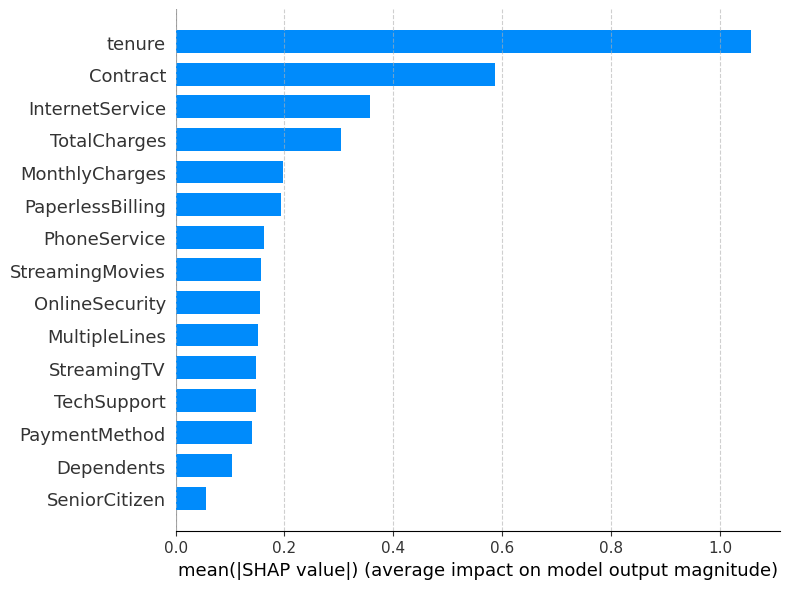

In [82]:
plot_feature_importance(log_reg, X_train_preprocessed, X_test_preprocessed, top_n=15, figsize=(8, 6))

На первом месте для логистической регрессии оказался признак **tenure** у которого наблюдалась наибольшая корреляция с таргетом **Churn**

### 2.3 Дерево решений

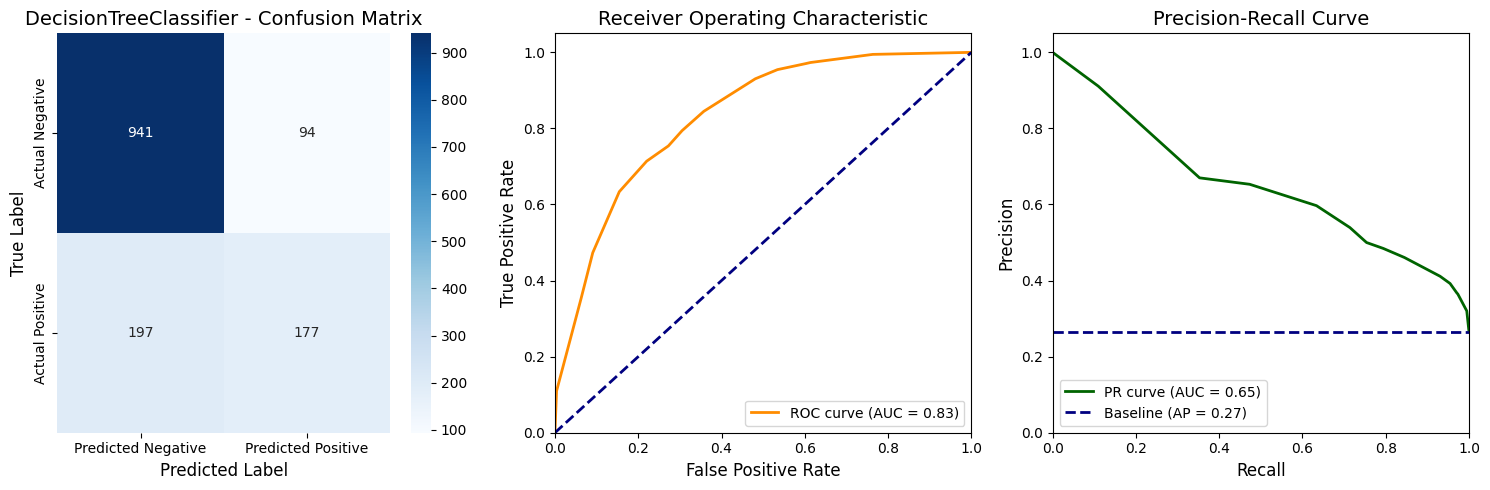


             DECISIONTREECLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8311
   PR AUC 0.6501
 F1 Score 0.7075
Precision 0.7400
   Recall 0.6912
 Accuracy 0.7935


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.653137 0.473262
Negative   0.826889 0.909179



In [45]:
decision_tree = DecisionTreeClassifier(random_state=SEED, max_depth=4)
decision_tree.fit(X_train_preprocessed, y_train)

y_pred = decision_tree.predict(X_test_preprocessed)
y_probs = decision_tree.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

decision_tree_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="DecisionTreeClassifier"
)

c:\Users\Kirill\Desktop\ML_Projects\ml-classification\plots.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  import seaborn as sns


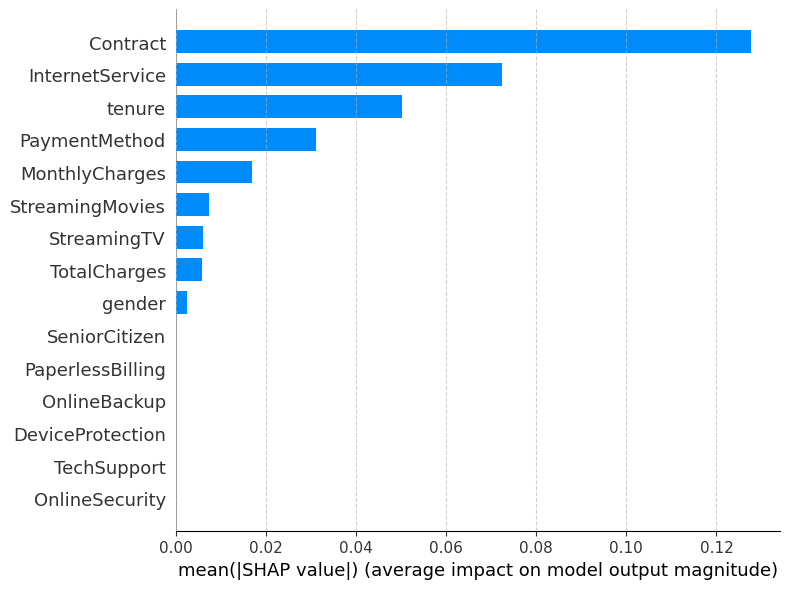

In [81]:
plot_feature_importance(decision_tree, X_train_preprocessed, X_test_preprocessed, top_n=15, figsize=(8, 6))

У дерева на первом месте оказался **Contract**. Разброс важности признаков меньше, однако важность большинства признаков равно нулю

### 2.4 Случайный лес

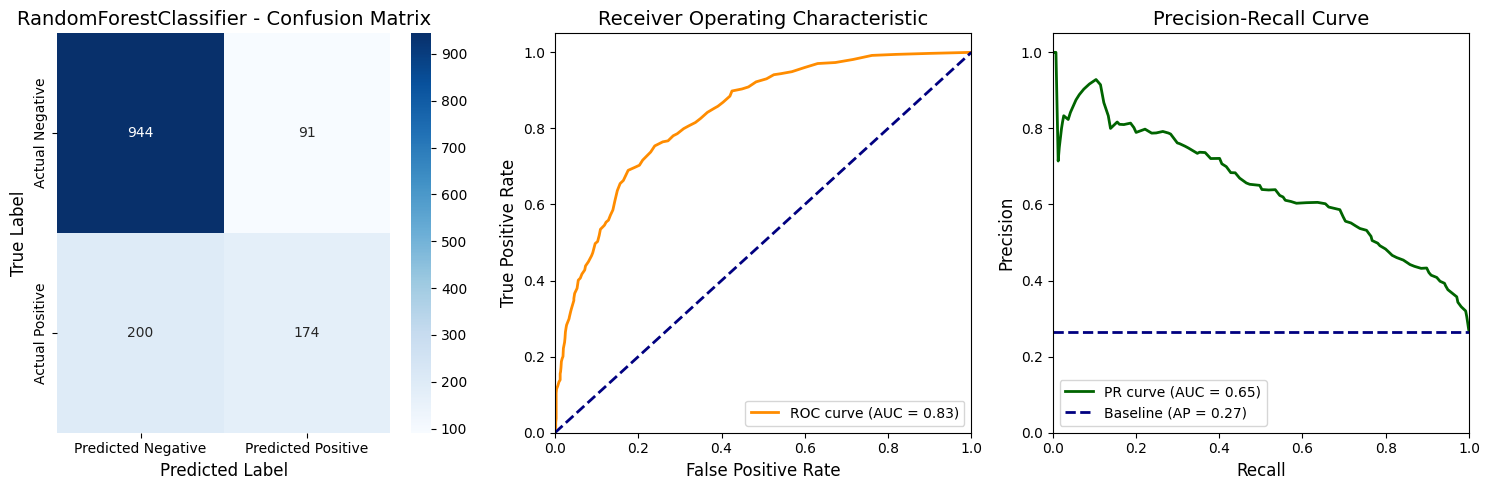


             RANDOMFORESTCLASSIFIER EVALUATION              

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8340
   PR AUC 0.6479
 F1 Score 0.7055
Precision 0.7409
   Recall 0.6887
 Accuracy 0.7935


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.656604 0.465241
Negative   0.825175 0.912077



In [84]:
random_forest = RandomForestClassifier(random_state=SEED)
random_forest.fit(X_train_preprocessed, y_train)

y_pred = random_forest.predict(X_test_preprocessed)
y_probs = random_forest.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

random_forest_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="RandomForestClassifier"
)

 99%|===================| 2796/2818 [01:59<00:00]        c:\Users\Kirill\Desktop\ML_Projects\ml-classification\plots.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  import seaborn as sns


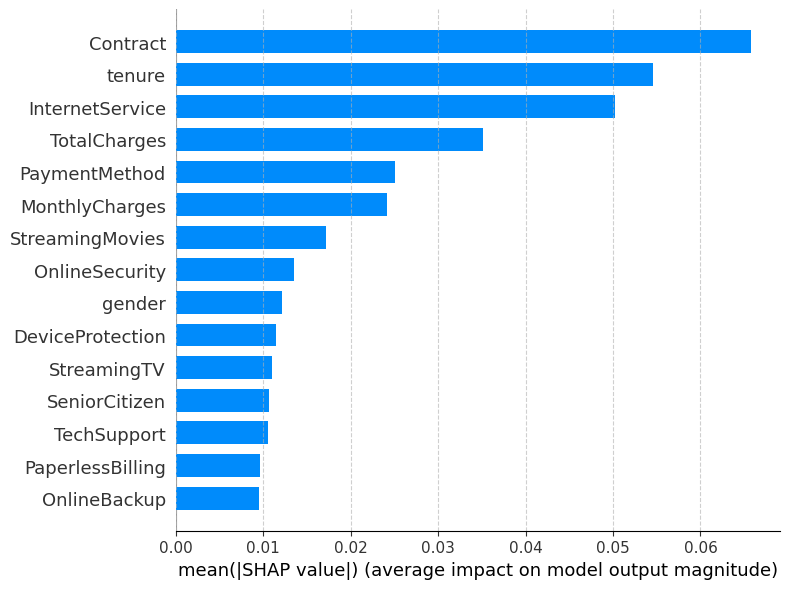

In [88]:
plot_feature_importance(random_forest, X_train_preprocessed, X_test_preprocessed, top_n=15, figsize=(8, 6))

У случайного леса разброс важности признаков еще меньше чем у дерева, также эта модель учитывает больше признаков для предсказания. 

Также модель обращает внимание на **Gender** (пол), что может быть не совсем правильно

### 2.5 LGBMClassifier

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1383
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


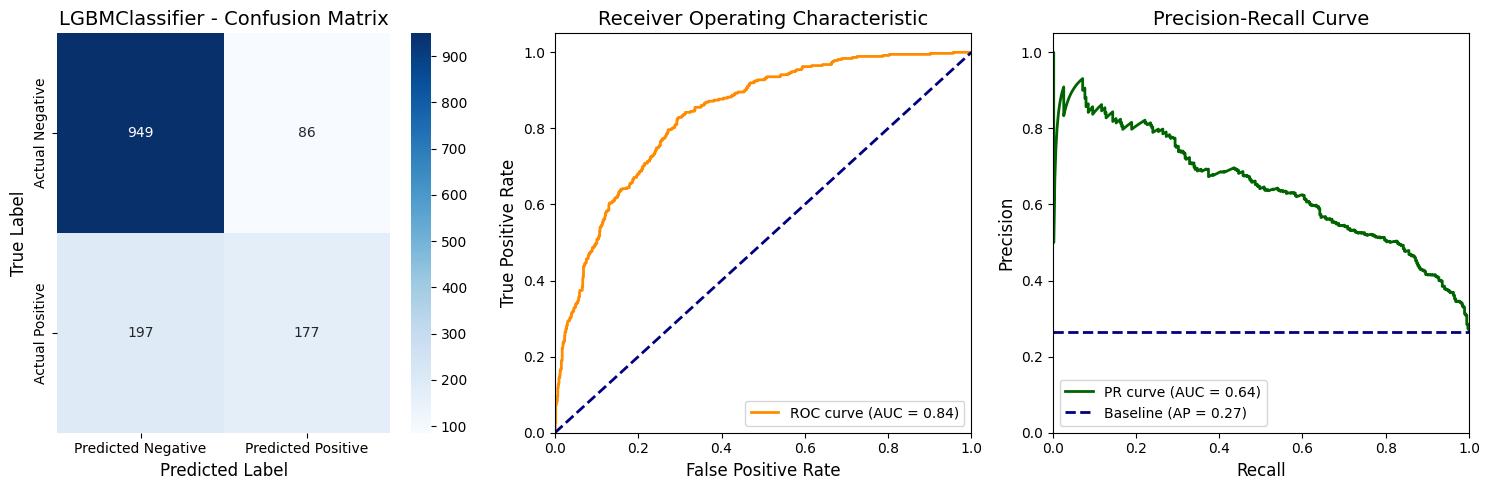


                 LGBMCLASSIFIER EVALUATION                  

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8351
   PR AUC 0.6447
 F1 Score 0.7130
Precision 0.7506
   Recall 0.6951
 Accuracy 0.7991


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.673004 0.473262
Negative   0.828098 0.916908



In [89]:
lgbm = LGBMClassifier(random_state=SEED)
lgbm.fit(X_train_preprocessed, y_train)

y_pred = lgbm.predict(X_test_preprocessed)
y_probs = lgbm.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

lgbm_metrics = evaluate_classification(
    y_test=y_test,
    y_pred=y_pred,
    y_probs=y_probs,
    model_name="LGBMClassifier"
)

c:\Users\Kirill\Desktop\ML_Projects\ml-classification\plots.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  from matplotlib.colors import LinearSegmentedColormap


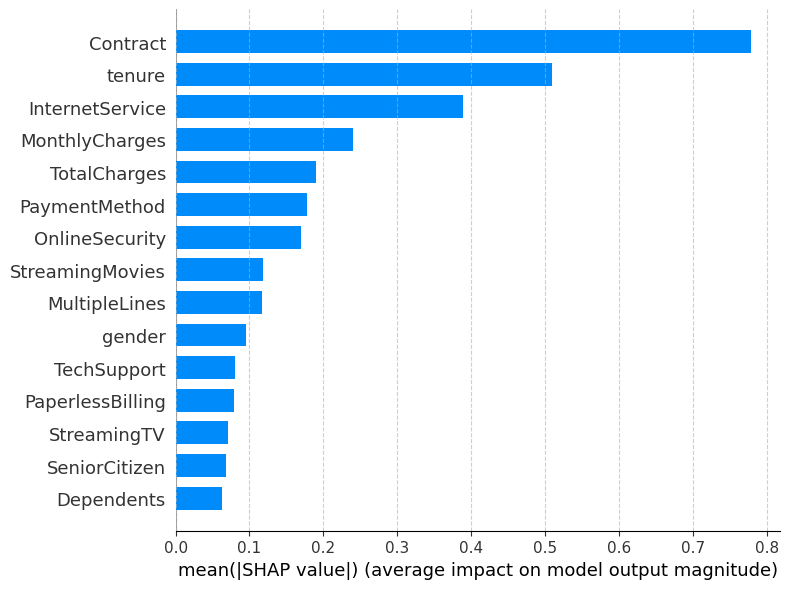

In [90]:
plot_feature_importance(lgbm, X_train_preprocessed, X_test_preprocessed, top_n=15, figsize=(8, 6))

LGBMClassifier отдает сильное препочтение признаку **Contract**. Важность признаков имеет сильный разброс

Эта модель тоже немного обращает внимание на **Gender** (пол) человека

### 2.6 CatBoostClassifier

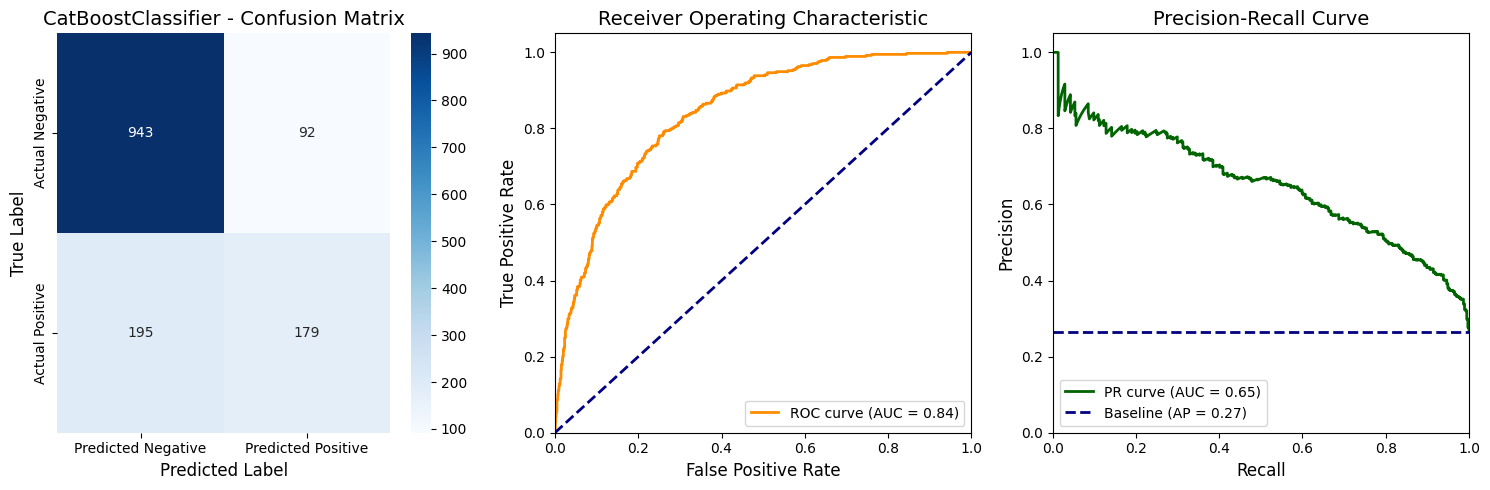


               CATBOOSTCLASSIFIER EVALUATION                

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8422
   PR AUC 0.6507
 F1 Score 0.7115
Precision 0.7446
   Recall 0.6949
 Accuracy 0.7963


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.660517 0.478610
Negative   0.828647 0.911111



In [91]:
catboost = CatBoostClassifier(
    random_state=SEED,
    verbose=0,
    task_type="CPU",
    allow_writing_files=False
)

catboost.fit(X_train_preprocessed, y_train)

y_pred = catboost.predict(X_test_preprocessed)
y_probs = catboost.predict_proba(X_test_preprocessed)[:, 1]  # For ROC curve

catboost_metrics = evaluate_classification(
    y_test=y_test, y_pred=y_pred, y_probs=y_probs, model_name="CatBoostClassifier"
)

 99%|===================| 1400/1409 [01:32<00:00]        c:\Users\Kirill\Desktop\ML_Projects\ml-classification\plots.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  from matplotlib.colors import LinearSegmentedColormap


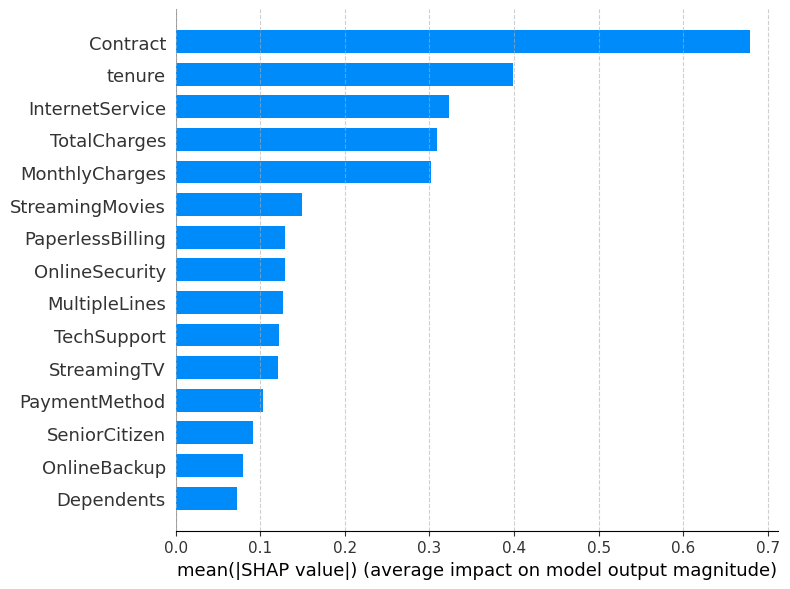

In [92]:
plot_feature_importance(catboost, X_train_preprocessed, X_test_preprocessed, top_n=15, figsize=(8, 6))

Catboost тоже отдает сильное предпочтение **Contract**, но важность остальных наиболее значимых признаков распределена более равномерно чем в других моделях.

Также Catboot не смотрит на **Gender** 

### 2.7 CatBoostClassifier (Raw categorical)

Попробуем подать Catboost заранее не обработаные категориальные признаки. Возможно он предобработает их лучшим способом.

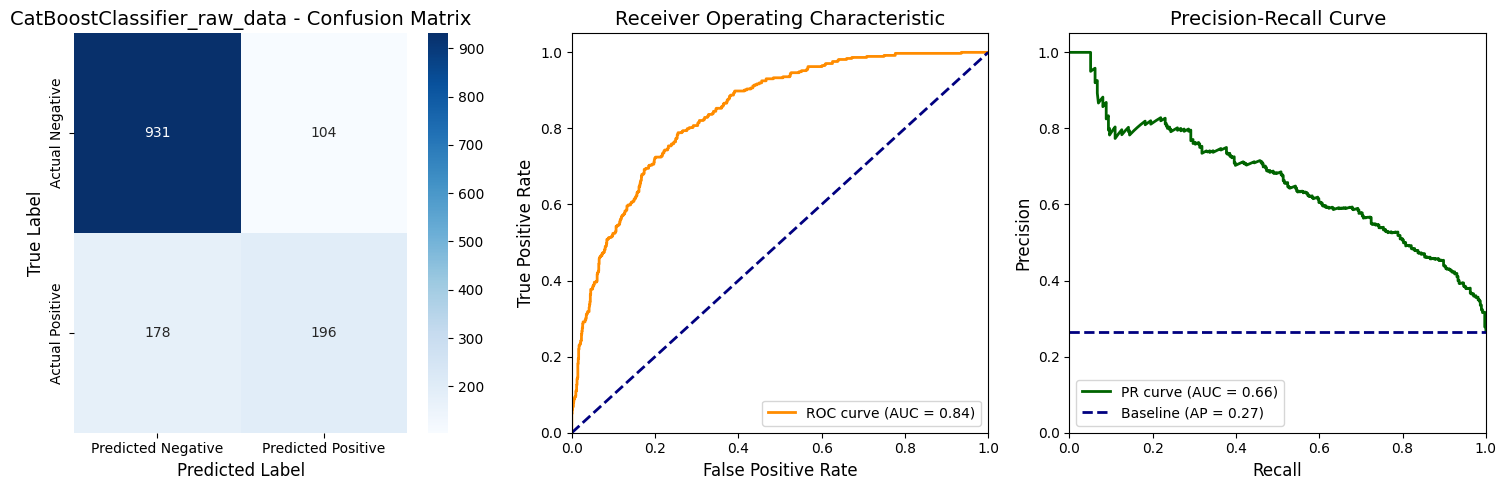


           CATBOOSTCLASSIFIER_RAW_DATA EVALUATION           

MAIN METRICS:
   Metric  Value
  ROC AUC 0.8431
   PR AUC 0.6613
 F1 Score 0.7250
Precision 0.7464
   Recall 0.7118
 Accuracy 0.7999


CLASSIFICATION REPORT:
   Class  Precision   Recall
Positive   0.653333 0.524064
Negative   0.839495 0.899517



In [93]:
catboost_raw_data = CatBoostClassifier(
    random_state=SEED,
    cat_features=CATEGORICAL_FEATURES_LIST,
    verbose=0,
    task_type="CPU",
    allow_writing_files=False
)

catboost_raw_data.fit(X_train, y_train)

y_pred = catboost_raw_data.predict(X_test)
y_probs = catboost_raw_data.predict_proba(X_test)[:, 1]  # For ROC curve

catboost_raw_data_metrics = evaluate_classification(
    y_test=y_test, y_pred=y_pred, y_probs=y_probs, model_name="CatBoostClassifier_raw_data"
)

Метрики увеличились совсем немного, в то время как время работы модели выросло в разы (5.2 vs 57.9 секунд)

### 2.8 Финальное сравнение метрик

In [96]:
final_metrics = {
    "dummy_classifier": dummy_classifier_metrics,
    "log_reg": log_reg_metrics,
    "decision_tree": decision_tree_metrics,
    "random_forest": random_forest_metrics,
    "lgbm": lgbm_metrics,
    "catboost": catboost_metrics,
    "catboost_raw_data": catboost_raw_data_metrics
}

result = pd.DataFrame(final_metrics.values(), index=final_metrics.keys())

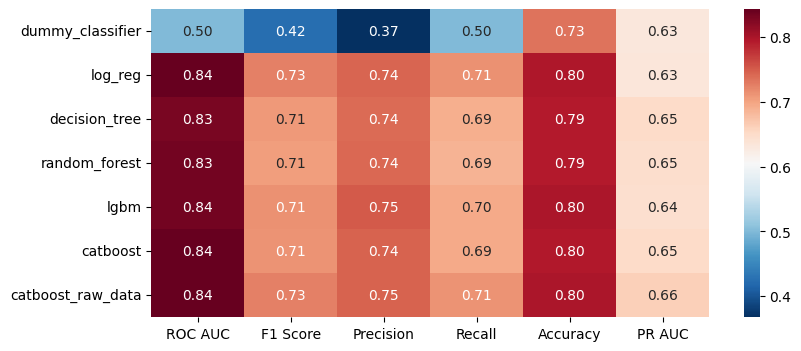

In [97]:
plt.figure(figsize=(9, 4))

sns.heatmap(result, cmap='RdBu_r', annot=True, fmt=".2f")
plt.show()

По метрикам хуже всех показал себя dummy_classifier. Остальные модели, по метрикам, практически не отличаются друг от друга.

Отбор лучшей модели можно будет произвести в зависимости от установленных требований:
- на какие признаки модель опирается для предсказания
- общая интерпретируемость предсказаний модели
- скорость работы модели (обучение и инференс)